# PRCP-1014 – Vaccine Prediction

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8')


In [2]:
features = pd.read_csv("features.csv")
labels = pd.read_csv("labels.csv")



In [3]:
features.head()
labels.head()


,respondent_id,h1n1_vaccine,seasonal_vaccine
0,0,0,0
1,1,0,1
2,2,0,0
3,3,0,1
4,4,0,0


In [4]:
features.shape, labels.shape


((26707, 36), (26707, 3))

In [5]:
df = features.copy()
df["Vaccination Coverage"] = labels.iloc[:, 0]
df.head()



,respondent_id,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,...,marital_status,rent_or_own,employment_status,hhs_geo_region,census_msa,household_adults,household_children,employment_industry,employment_occupation,Vaccination Coverage
0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,...,Not Married,Own,Not in Labor Force,oxchjgsf,Non-MSA,0.0,0.0,NaN,NaN,0
1,1,3.0,2.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,...,Not Married,Rent,Employed,bhuqouqj,"MSA, Not Principle City",0.0,0.0,pxcmvdjn,xgwztkwe,1
2,2,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,Not Married,Own,Employed,qufhixun,"MSA, Not Principle City",2.0,0.0,rucpziij,xtkaffoo,2
3,3,1.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,...,Not Married,Rent,Not in Labor Force,lrircsnp,"MSA, Principle City",0.0,0.0,NaN,NaN,3
4,4,2.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,...,Married,Own,Employed,qufhixun,"MSA, Not Principle City",1.0,0.0,wxleyezf,emcorrxb,4


In [6]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26707 entries, 0 to 26706
Data columns (total 37 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   respondent_id                26707 non-null  int64  
 1   h1n1_concern                 26615 non-null  float64
 2   h1n1_knowledge               26591 non-null  float64
 3   behavioral_antiviral_meds    26636 non-null  float64
 4   behavioral_avoidance         26499 non-null  float64
 5   behavioral_face_mask         26688 non-null  float64
 6   behavioral_wash_hands        26665 non-null  float64
 7   behavioral_large_gatherings  26620 non-null  float64
 8   behavioral_outside_home      26625 non-null  float64
 9   behavioral_touch_face        26579 non-null  float64
 10  doctor_recc_h1n1             24547 non-null  float64
 11  doctor_recc_seasonal         24547 non-null  float64
 12  chronic_med_condition        25736 non-null  float64
 13  child_under_6_mo

In [7]:
df.describe()


,respondent_id,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,...,health_insurance,opinion_h1n1_vacc_effective,opinion_h1n1_risk,opinion_h1n1_sick_from_vacc,opinion_seas_vacc_effective,opinion_seas_risk,opinion_seas_sick_from_vacc,household_adults,household_children,Vaccination Coverage
count,26707.000000,26615.000000,26591.000000,26636.000000,26499.000000,26688.000000,26665.000000,26620.00000,26625.000000,26579.000000,...,14433.00000,26316.000000,26319.000000,26312.000000,26245.000000,26193.000000,26170.000000,26458.000000,26458.000000,26707.000000
mean,13353.000000,1.618486,1.262532,0.048844,0.725612,0.068982,0.825614,0.35864,0.337315,0.677264,...,0.87972,3.850623,2.342566,2.357670,4.025986,2.719162,2.118112,0.886499,0.534583,13353.000000
std,7709.791156,0.910311,0.618149,0.215545,0.446214,0.253429,0.379448,0.47961,0.472802,0.467531,...,0.32530,1.007436,1.285539,1.362766,1.086565,1.385055,1.332950,0.753422,0.928173,7709.791156
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,...,0.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000
25%,6676.500000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.00000,0.000000,0.000000,...,1.00000,3.000000,1.000000,1.000000,4.000000,2.000000,1.000000,0.000000,0.000000,6676.500000
50%,13353.000000,2.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.00000,0.000000,1.000000,...,1.00000,4.000000,2.000000,2.000000,4.000000,2.000000,2.000000,1.000000,0.000000,13353.000000
75%,20029.500000,2.000000,2.000000,0.000000,1.000000,0.000000,1.000000,1.00000,1.000000,1.000000,...,1.00000,5.000000,4.000000,4.000000,5.000000,4.000000,4.000000,1.000000,1.000000,20029.500000
max,26706.000000,3.000000,2.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,...,1.00000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,3.000000,3.000000,26706.000000


In [8]:
df.isnull().sum()


respondent_id                      0
h1n1_concern                      92
h1n1_knowledge                   116
behavioral_antiviral_meds         71
behavioral_avoidance             208
behavioral_face_mask              19
behavioral_wash_hands             42
behavioral_large_gatherings       87
behavioral_outside_home           82
behavioral_touch_face            128
doctor_recc_h1n1                2160
doctor_recc_seasonal            2160
chronic_med_condition            971
child_under_6_months             820
health_worker                    804
health_insurance               12274
opinion_h1n1_vacc_effective      391
opinion_h1n1_risk                388
opinion_h1n1_sick_from_vacc      395
opinion_seas_vacc_effective      462
opinion_seas_risk                514
opinion_seas_sick_from_vacc      537
age_group                          0
education                       1407
race                               0
sex                                0
income_poverty                  4423
m

- Missing values are present in the dataset, which is common in
public health data due to inconsistent reporting across regions
and time periods.


# Target Variable Distribution

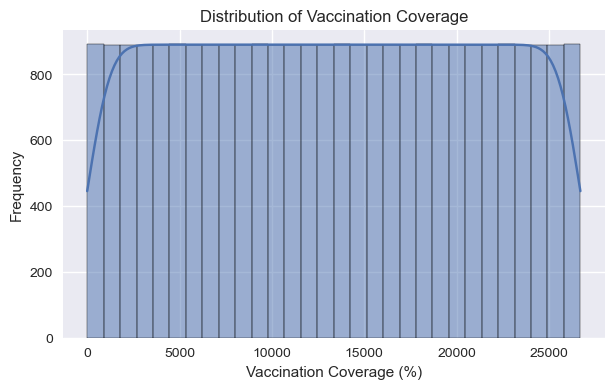

In [9]:
plt.figure(figsize=(7,4))
sns.histplot(df["Vaccination Coverage"], kde=True)
plt.title("Distribution of Vaccination Coverage")
plt.xlabel("Vaccination Coverage (%)")
plt.ylabel("Frequency")
plt.show()


- The target variable shows a wide spread, indicating non-uniform
vaccination levels across observations.


# Distribution of ALL Numerical Features

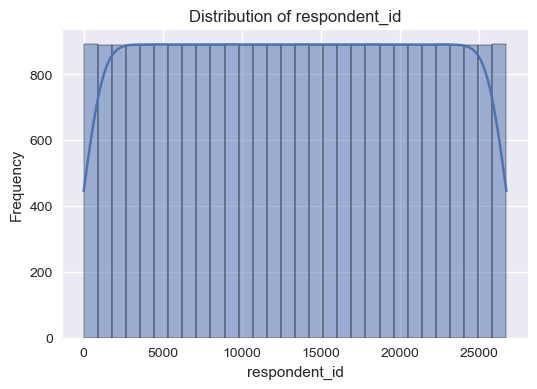

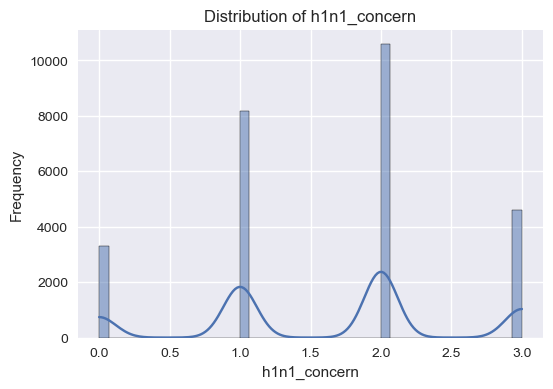

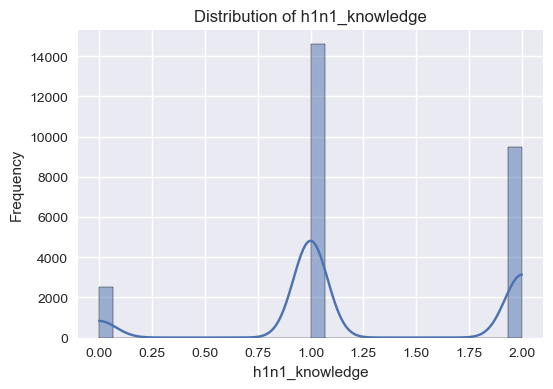

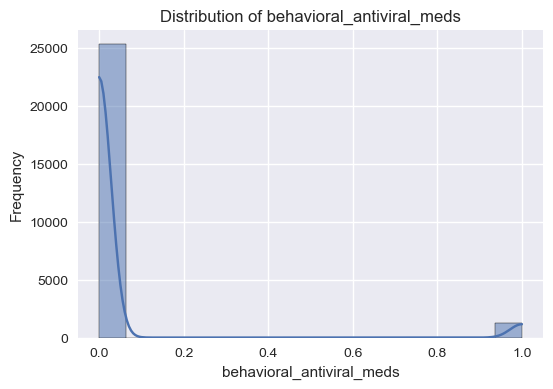

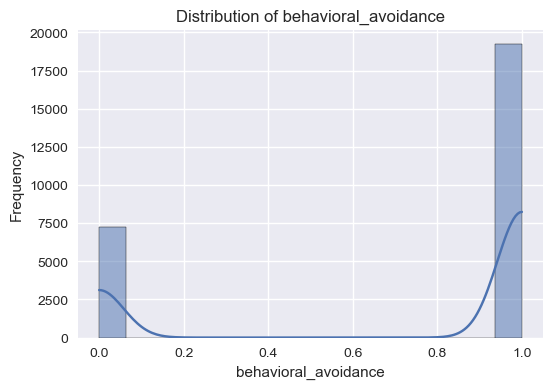

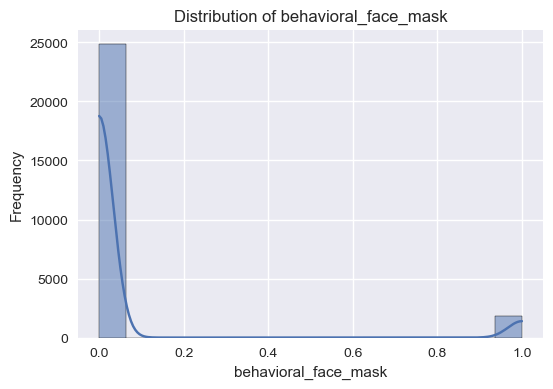

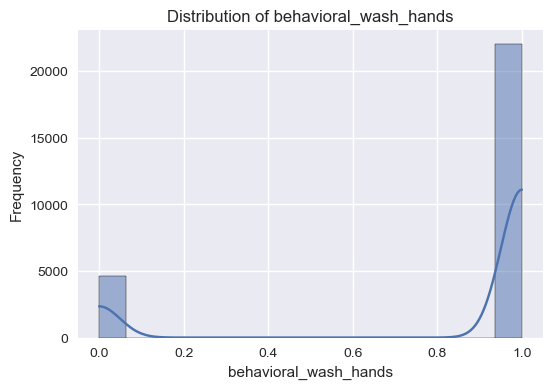

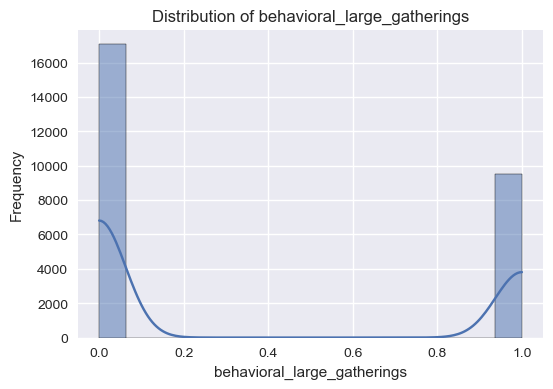

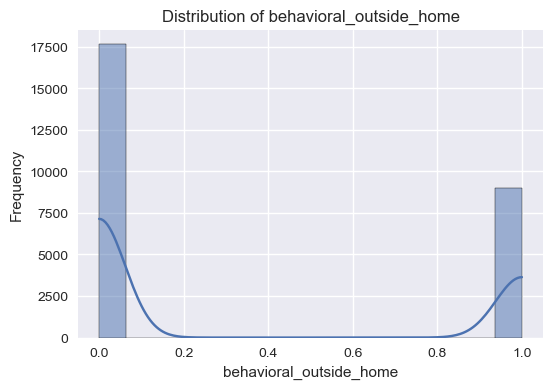

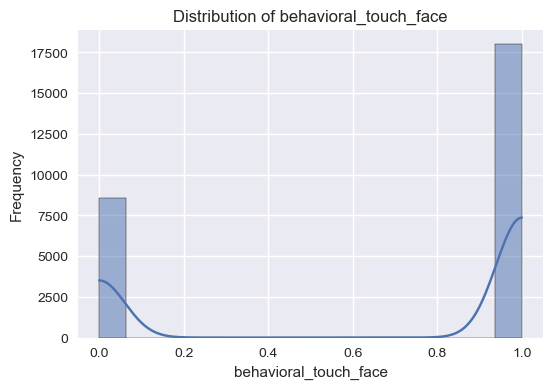

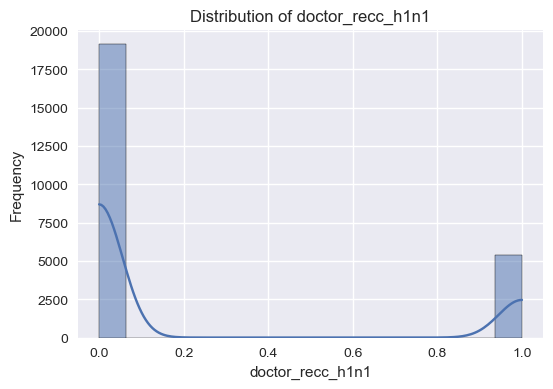

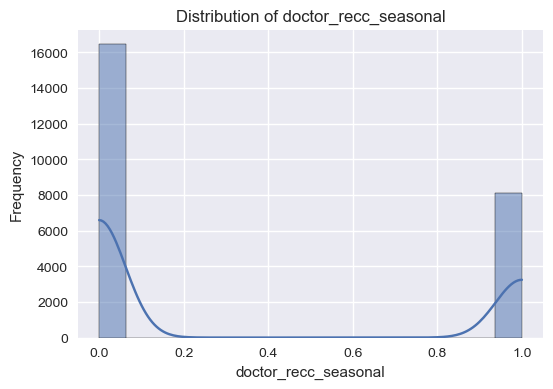

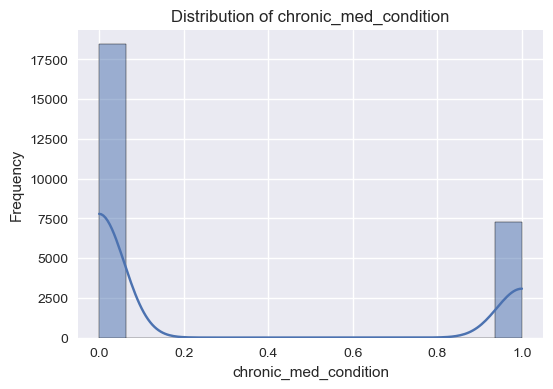

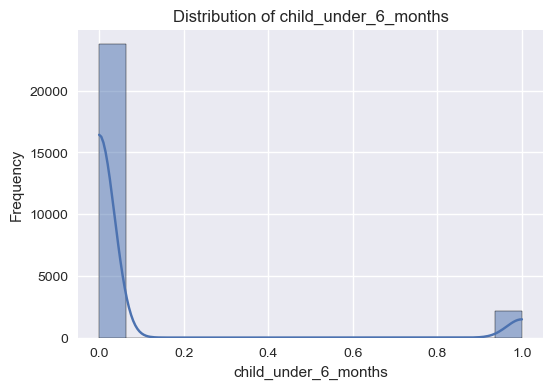

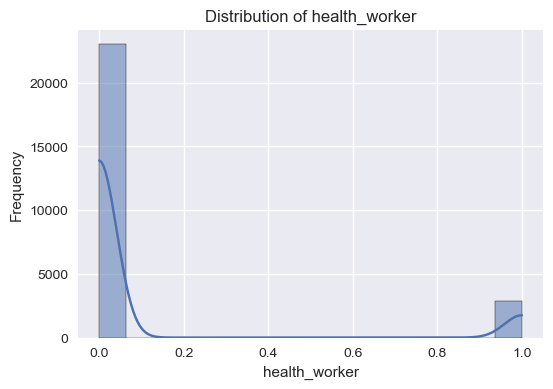

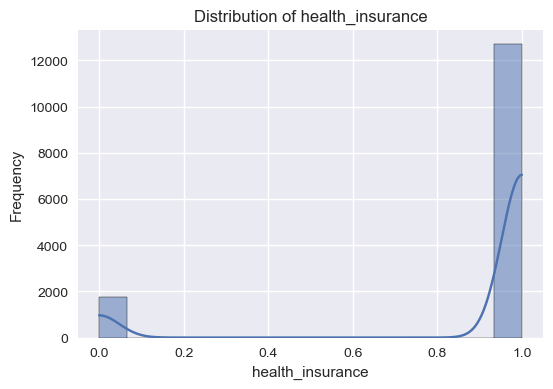

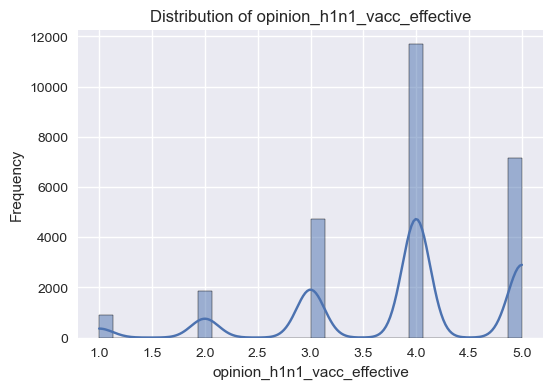

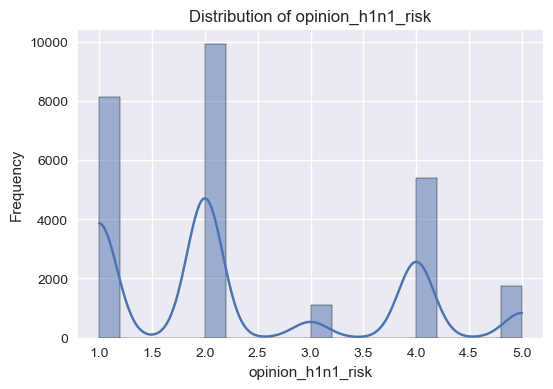

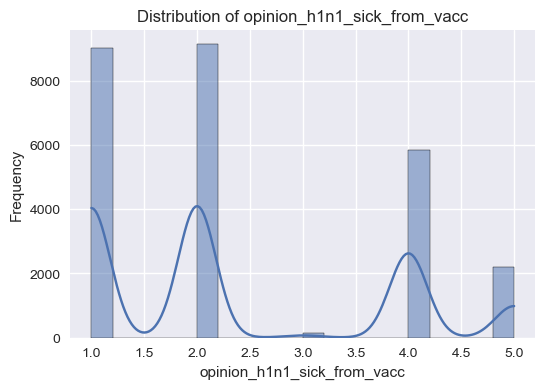

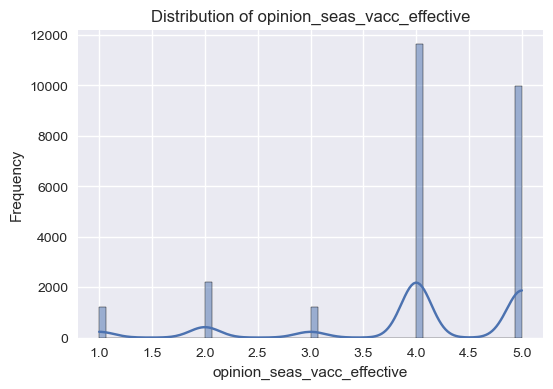

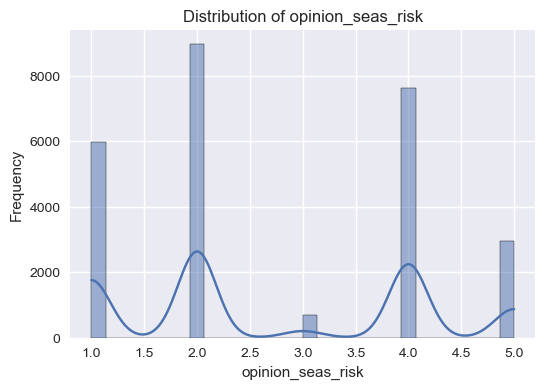

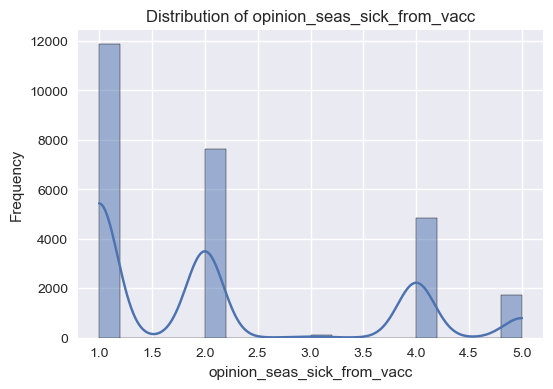

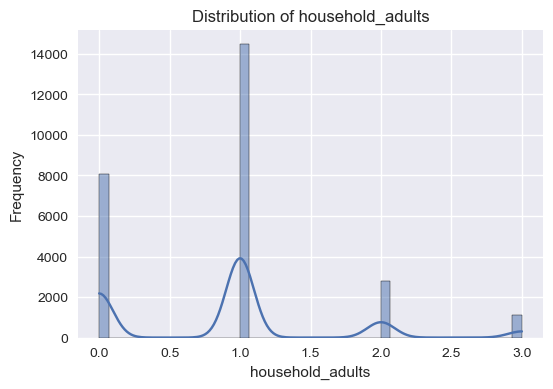

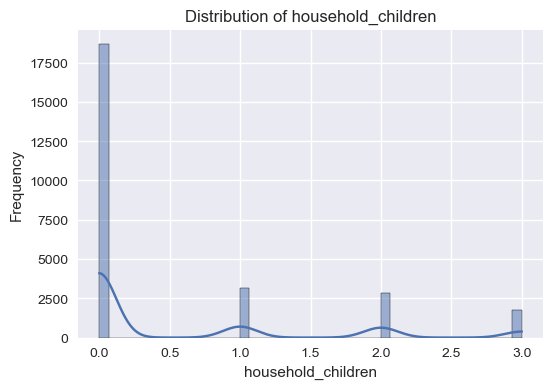

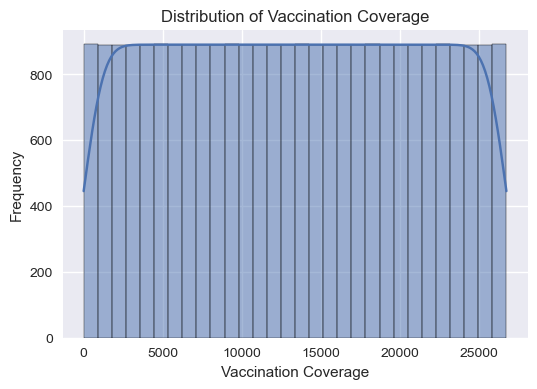

In [10]:
num_cols = df.select_dtypes(include=["int64", "float64"]).columns

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()


- Distribution plots help understand skewness, spread, and overall
behavior of numerical features.


 # Boxplots for Outlier Detection

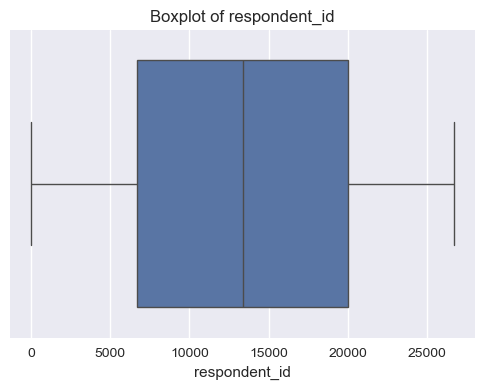

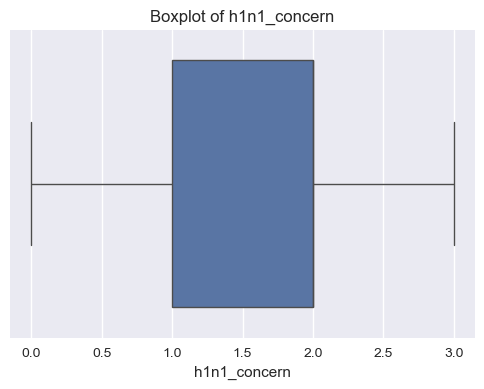

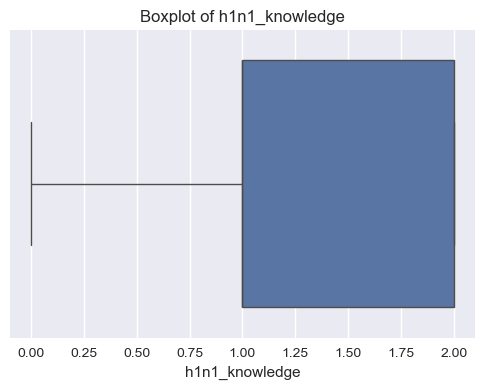

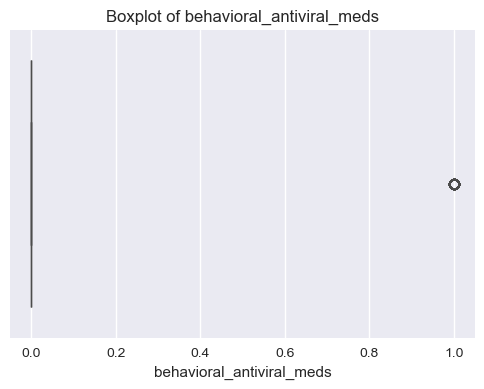

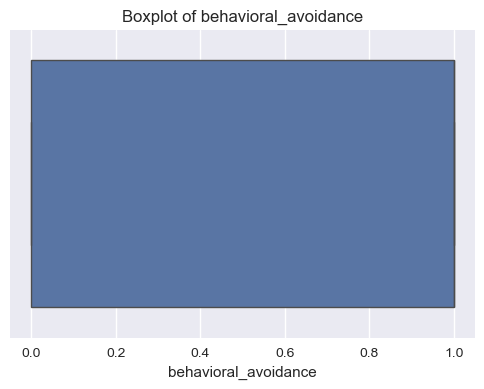

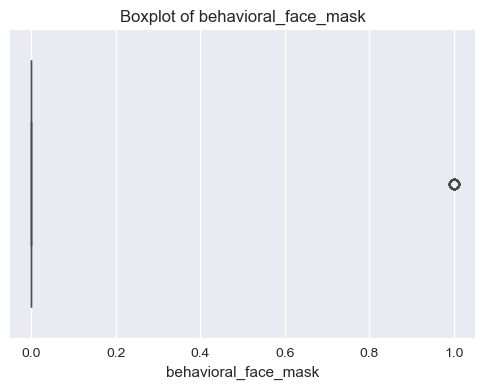

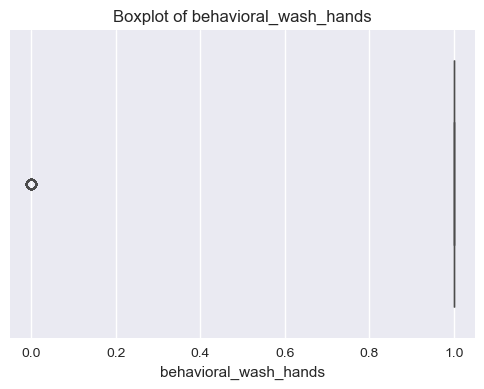

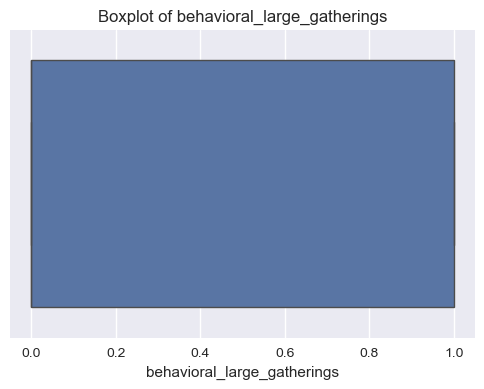

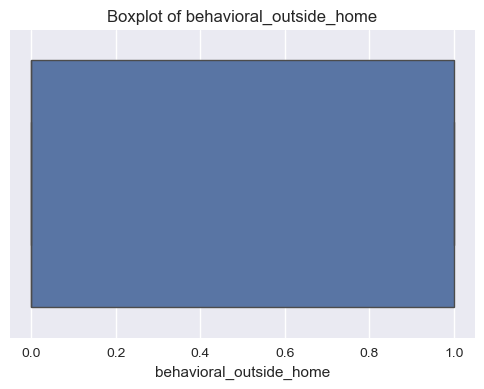

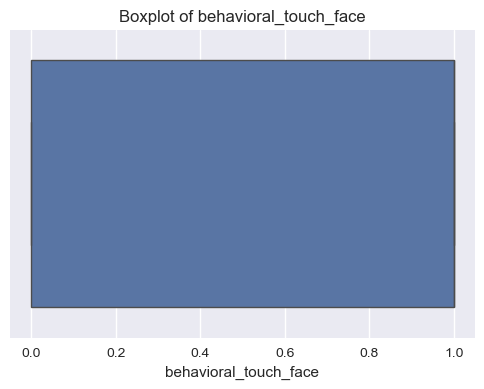

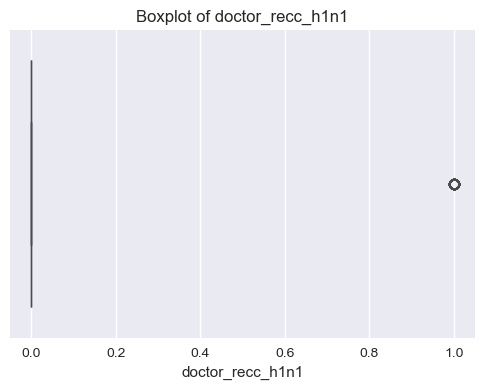

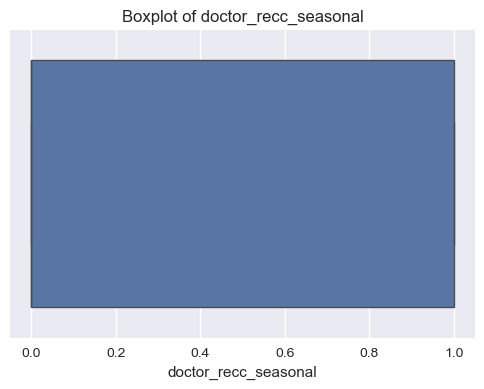

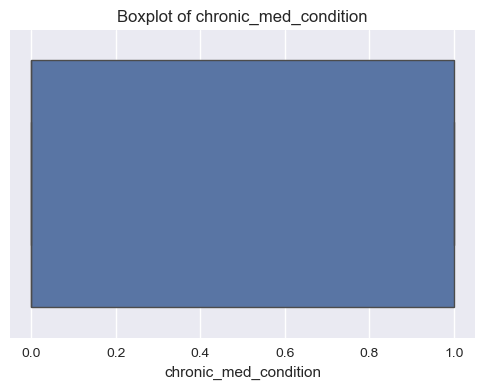

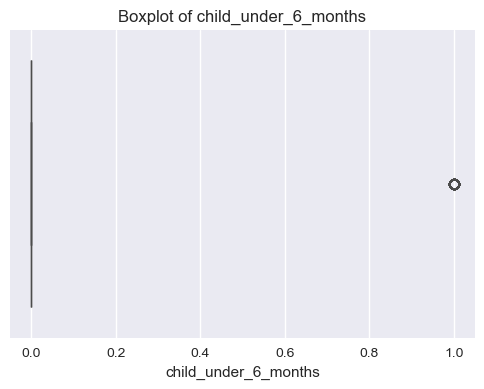

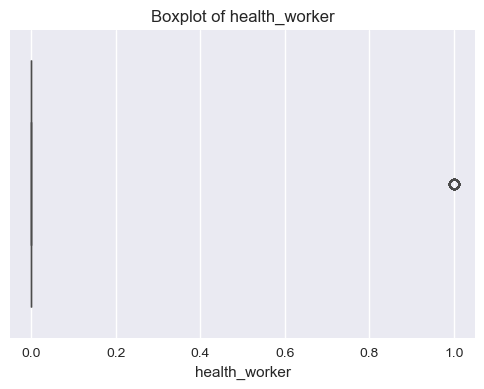

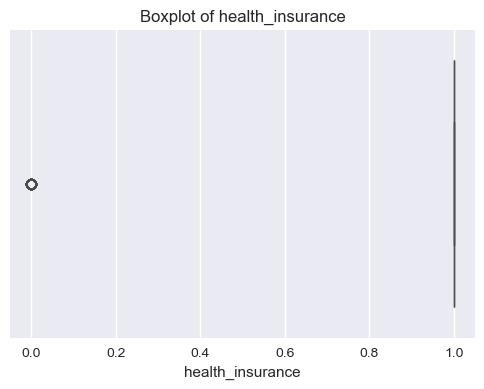

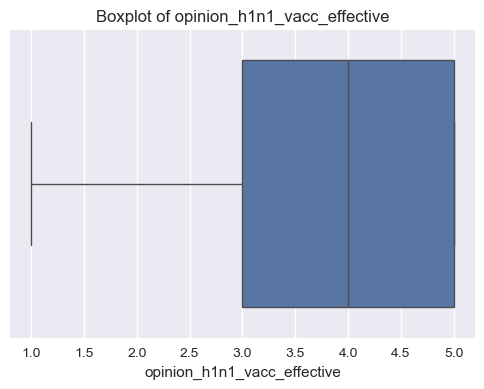

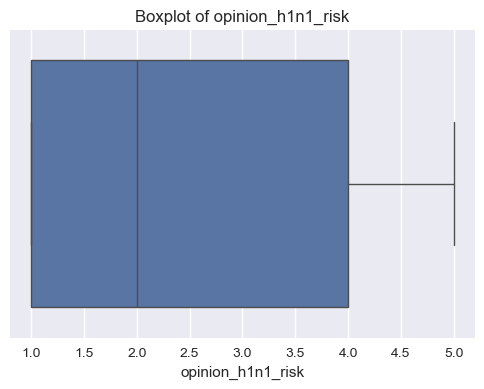

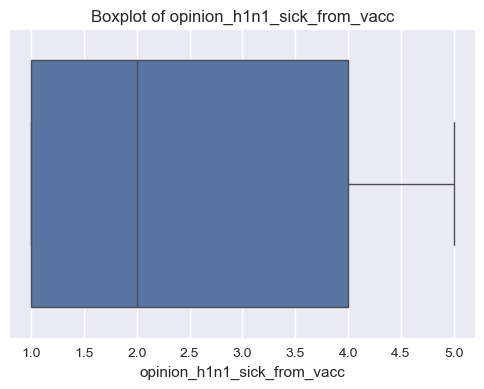

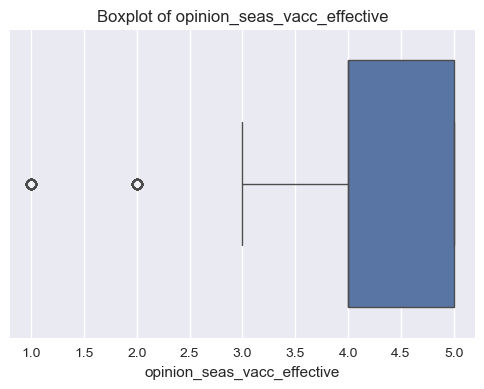

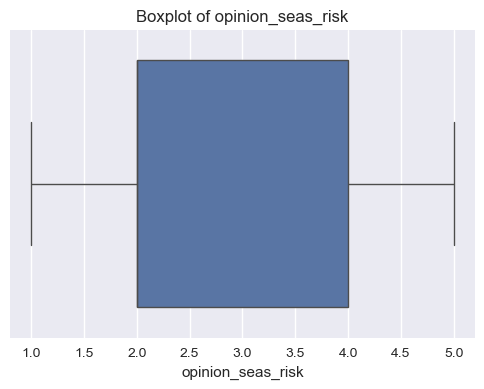

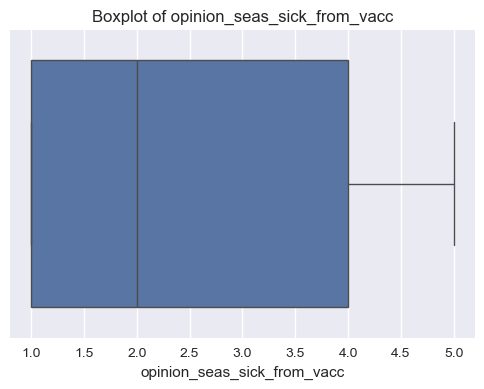

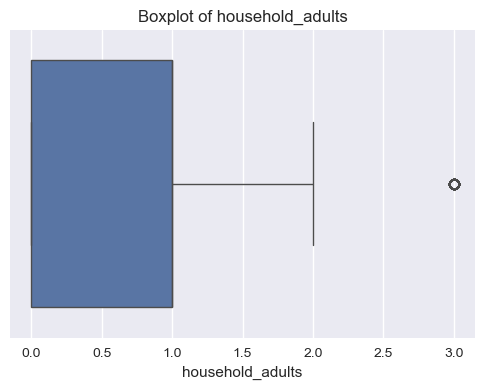

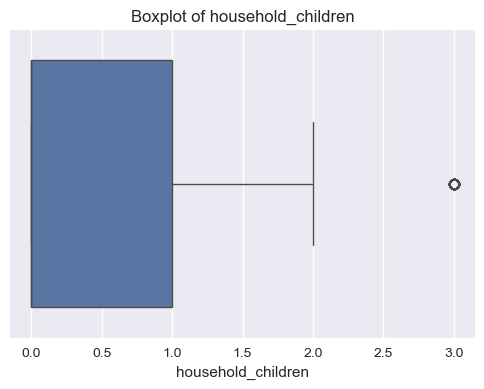

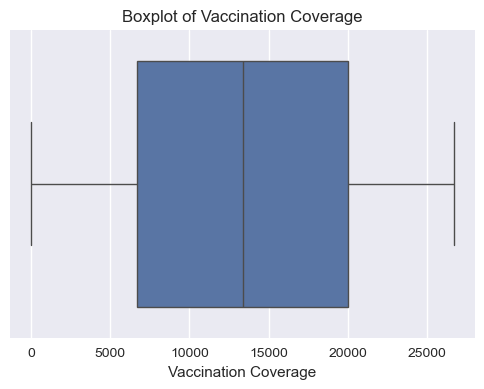

In [11]:
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()


- Boxplots are used to identify potential outliers and extreme values
that may impact model performance.


# Feature vs Target Relationships

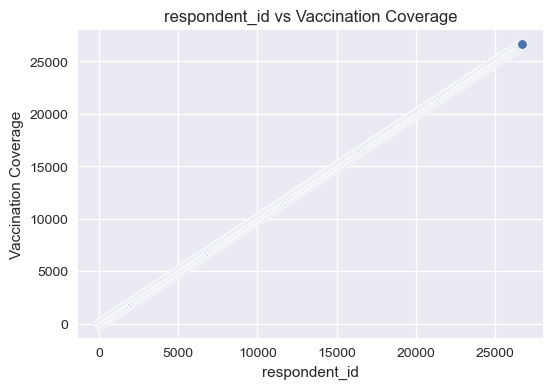

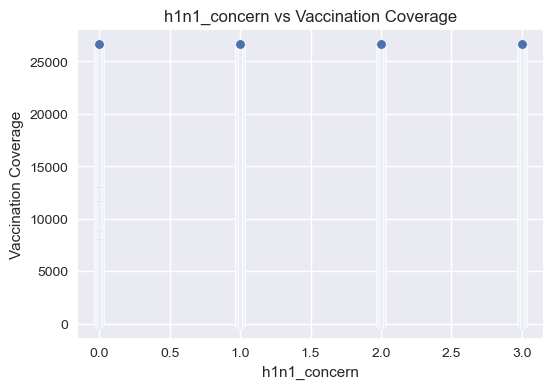

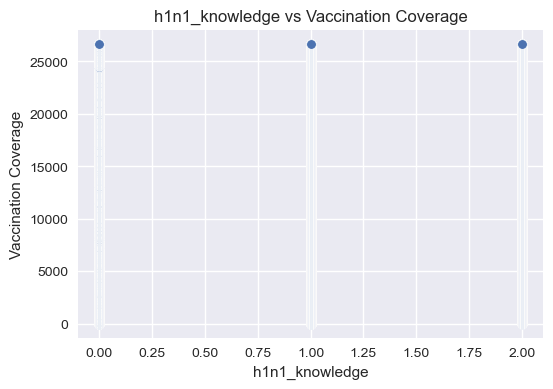

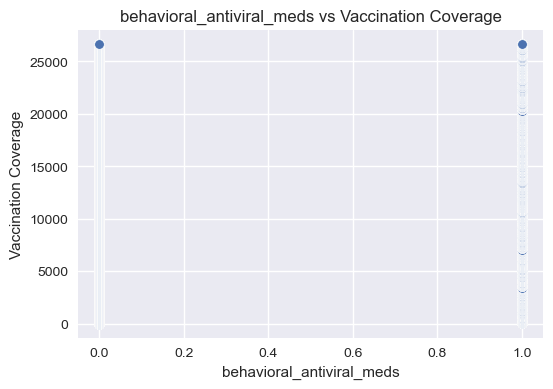

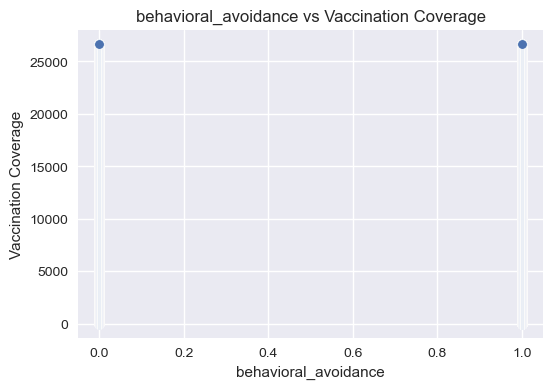

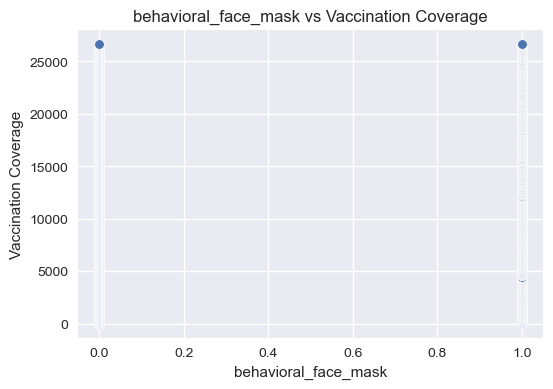

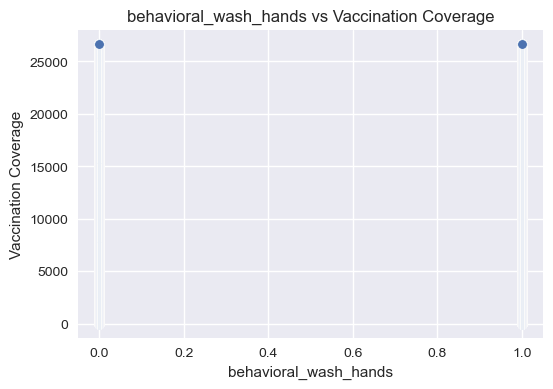

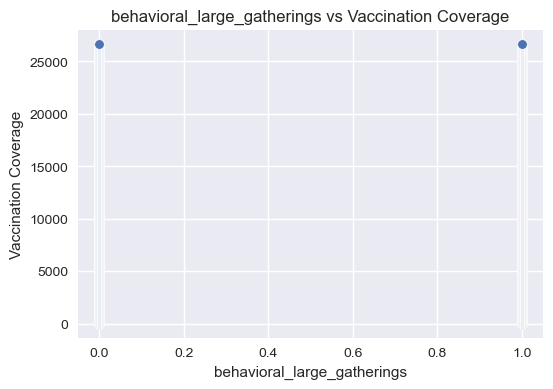

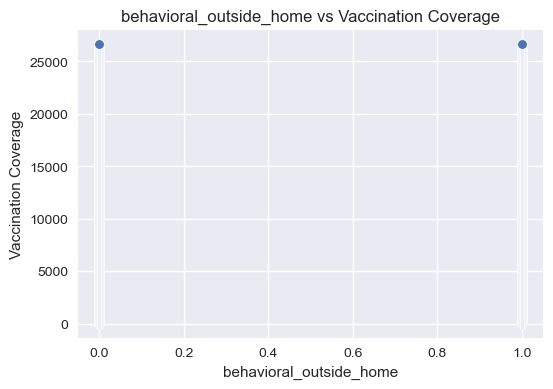

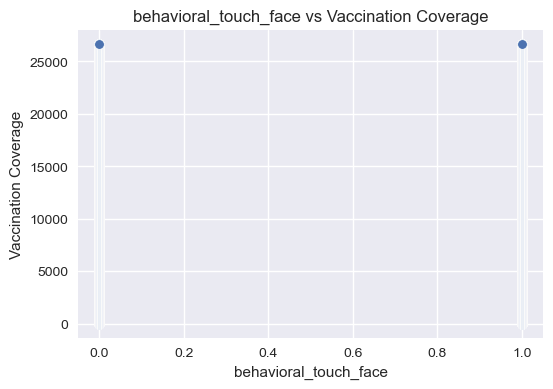

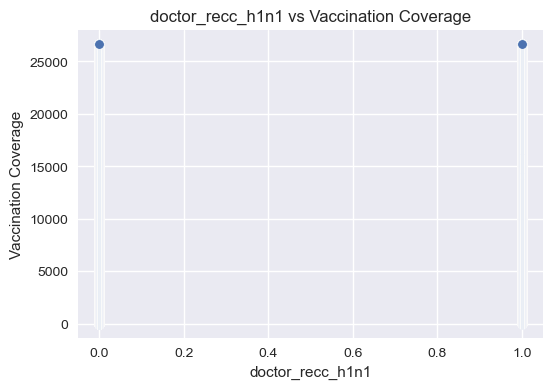

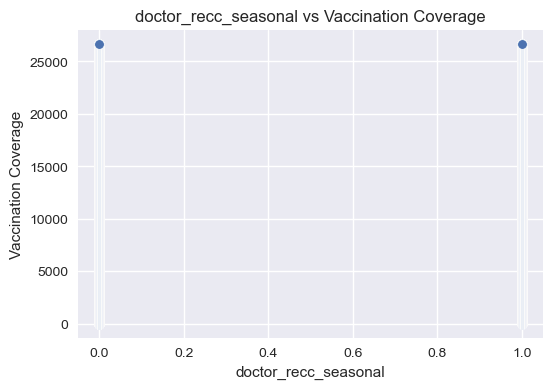

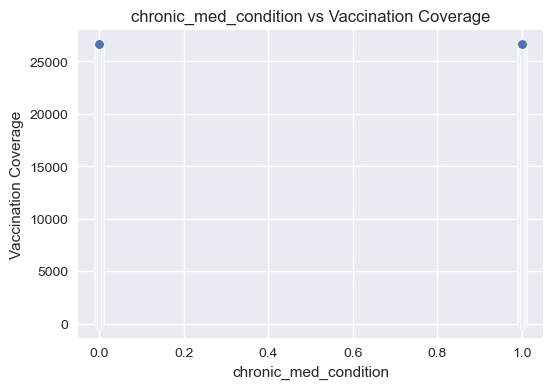

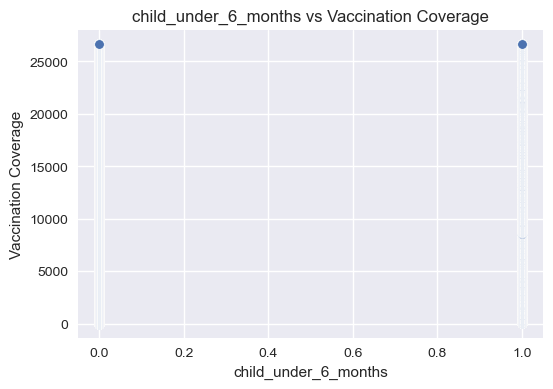

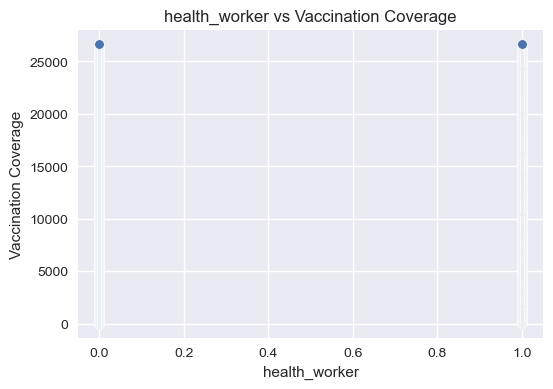

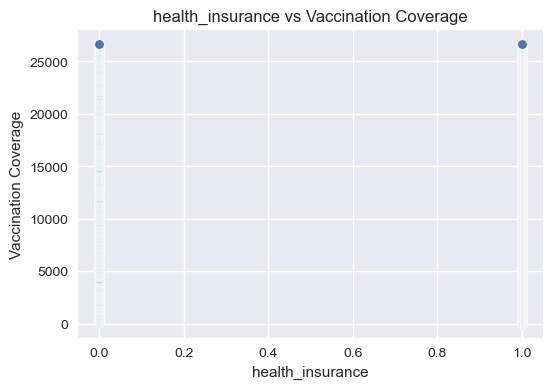

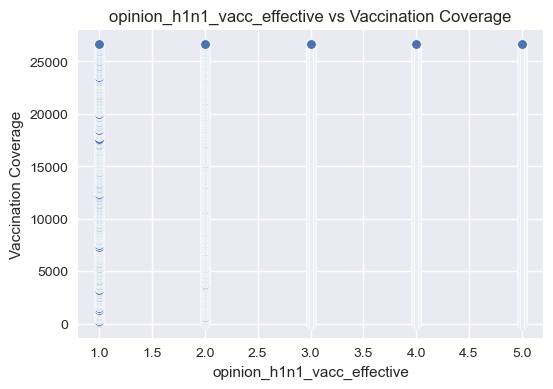

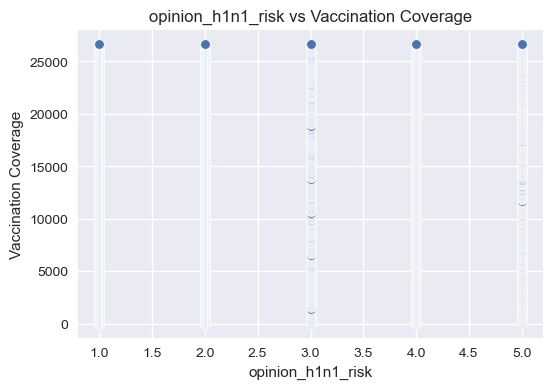

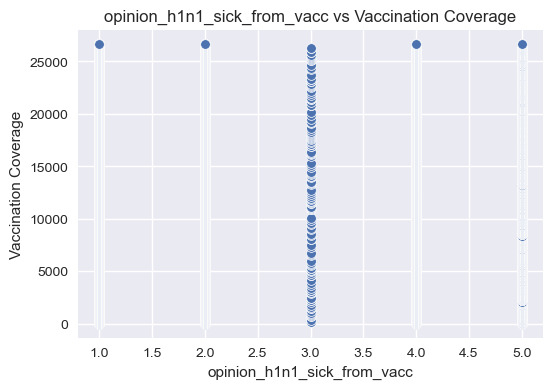

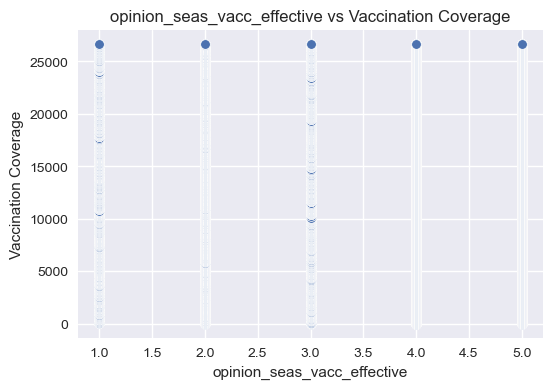

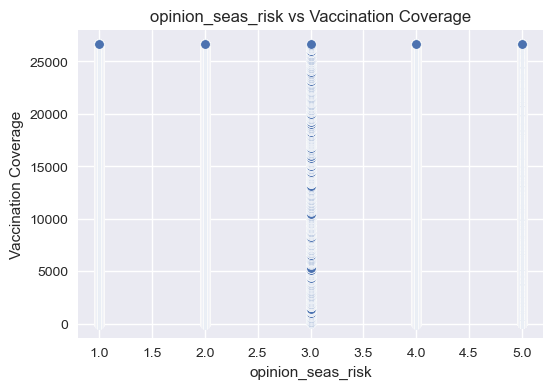

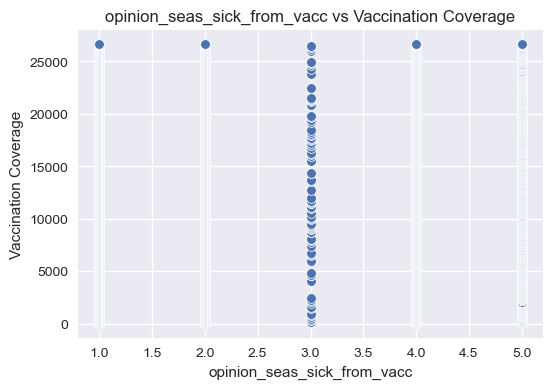

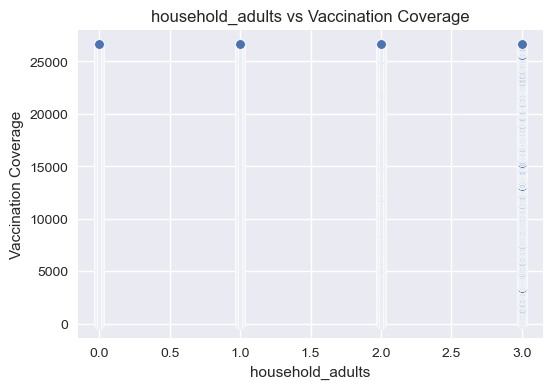

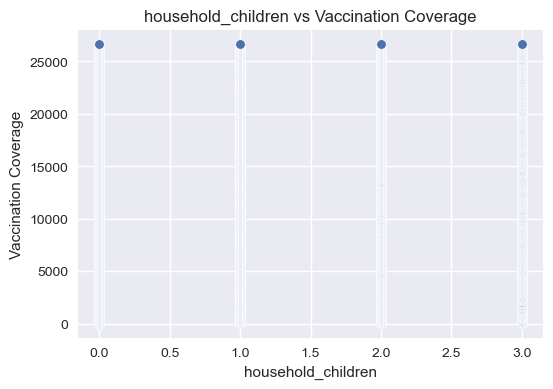

In [12]:
target = "Vaccination Coverage"

for col in num_cols:
    if col != target:
        plt.figure(figsize=(6,4))
        sns.scatterplot(x=df[col], y=df[target])
        plt.title(f"{col} vs {target}")
        plt.show()


- Scatter plots reveal non-linear relationships between input features
and vaccination coverage.


# Correlation Heatmap


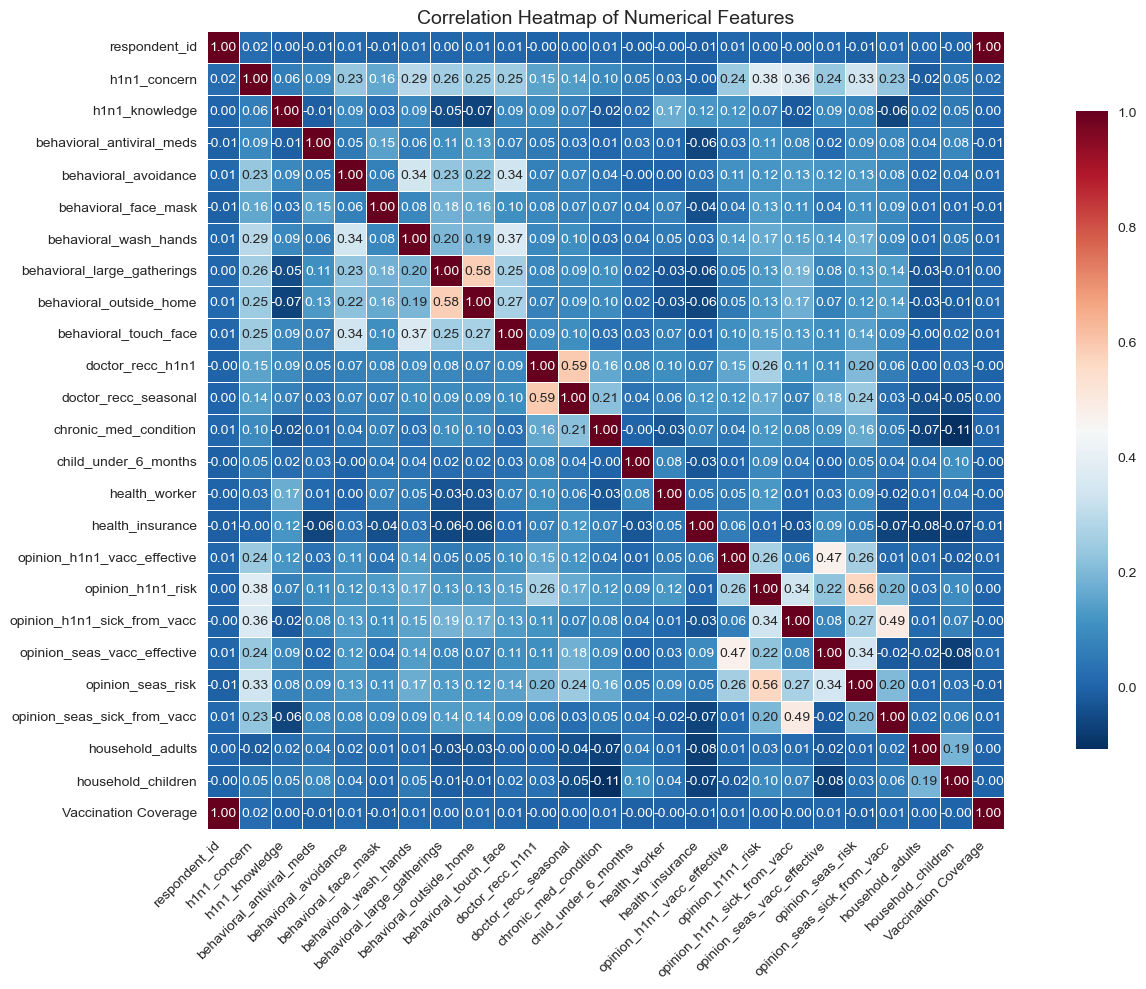

In [13]:
plt.figure(figsize=(15,10))

corr = df[num_cols].corr()

sns.heatmap(
    corr,
    annot=True,              
    fmt=".2f",               
    cmap="RdBu_r",           
    linewidths=0.5,          
    linecolor="white",
    square=True,             
    cbar_kws={"shrink": 0.8} 
)

plt.title("Correlation Heatmap of Numerical Features", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()



- Correlation analysis shows varying levels of association between
features, indicating that multiple features influence vaccination coverage.


- Although multiple visualizations were explored during deep EDA,
only the most informative plots will be retained in the final
report to avoid redundancy and maintain clarity.


In [14]:
df.isnull().sum()


respondent_id                      0
h1n1_concern                      92
h1n1_knowledge                   116
behavioral_antiviral_meds         71
behavioral_avoidance             208
behavioral_face_mask              19
behavioral_wash_hands             42
behavioral_large_gatherings       87
behavioral_outside_home           82
behavioral_touch_face            128
doctor_recc_h1n1                2160
doctor_recc_seasonal            2160
chronic_med_condition            971
child_under_6_months             820
health_worker                    804
health_insurance               12274
opinion_h1n1_vacc_effective      391
opinion_h1n1_risk                388
opinion_h1n1_sick_from_vacc      395
opinion_seas_vacc_effective      462
opinion_seas_risk                514
opinion_seas_sick_from_vacc      537
age_group                          0
education                       1407
race                               0
sex                                0
income_poverty                  4423
m

In [15]:
from sklearn.impute import SimpleImputer

# Separate numerical and categorical columns
num_cols = df.select_dtypes(include=["int64", "float64"]).columns
cat_cols = df.select_dtypes(include=["object"]).columns

# Numerical imputation
num_imputer = SimpleImputer(strategy="median")
df[num_cols] = num_imputer.fit_transform(df[num_cols])

# Categorical imputation
cat_imputer = SimpleImputer(strategy="most_frequent")
df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])


- Median imputation was used for numerical features to reduce the influence
of outliers, while most frequent value imputation was applied to
categorical features to preserve category consistency.


In [16]:
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = np.clip(df[col], lower, upper)


- Outliers were capped using the IQR method instead of removal,
as extreme values may represent real-world vaccination behavior.


# Categorical Encoding

- Categorical variables were encoded using label encoding to convert
them into numerical form suitable for machine learning algorithms.


# Feature–Target Split

In [17]:
cat_cols = df.select_dtypes(include=["object"]).columns
num_cols = df.select_dtypes(include=["int64", "float64"]).columns


In [18]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])


In [19]:
X = df.drop("Vaccination Coverage", axis=1)
y = df["Vaccination Coverage"]


In [20]:
X.shape, y.shape


((26707, 36), (26707,))

# Feature Scaling

In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# Train–Test Split

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)


# Evaluation Metrics

In [23]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def evaluate_model(model_name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return {
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }


- MAE and RMSE measure prediction error magnitude, while R² indicates
how well the model explains variance in the target variable.


In [24]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

lr_result = evaluate_model("Linear Regression", y_test, y_pred_lr)
lr_result


{'Model': 'Linear Regression',
 'MAE': 2.483489182845695e-11,
 'RMSE': np.float64(2.9687303896982045e-11),
 'R2': 1.0}

- Linear Regression is used as a baseline model to understand how well
a simple linear relationship can explain vaccination trends.


In [25]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

rf_result = evaluate_model("Random Forest", y_test, y_pred_rf)
rf_result


{'Model': 'Random Forest',
 'MAE': 0.7711840134780951,
 'RMSE': np.float64(0.9575045247025651),
 'R2': 0.9999999844745262}

 - Random Forest captures non-linear relationships and interactions
between features, making it suitable for complex real-world data.


In [26]:
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.1,
    random_state=42
)

gbr.fit(X_train, y_train)

y_pred_gbr = gbr.predict(X_test)

gbr_result = evaluate_model("Gradient Boosting", y_test, y_pred_gbr)
gbr_result


{'Model': 'Gradient Boosting',
 'MAE': 34.464898454206605,
 'RMSE': np.float64(44.31198092265221),
 'R2': 0.9999667489377844}

- Gradient Boosting builds models sequentially to correct previous errors,
often achieving high accuracy on structured tabular data.


In [27]:
results = []
results.append(lr_result)
results.append(rf_result)
results.append(gbr_result)

results_df = pd.DataFrame(results)
results_df


,Model,MAE,RMSE,R2
0,Linear Regression,2.483489e-11,2.968730e-11,1.000000
1,Random Forest,7.711840e-01,9.575045e-01,1.000000
2,Gradient Boosting,3.446490e+01,4.431198e+01,0.999967


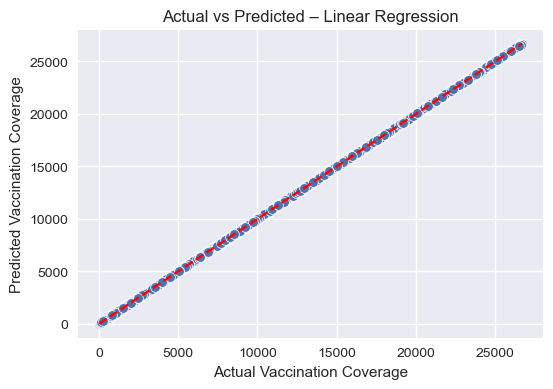

In [28]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=y_test, y=y_pred_lr)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')
plt.xlabel("Actual Vaccination Coverage")
plt.ylabel("Predicted Vaccination Coverage")
plt.title("Actual vs Predicted – Linear Regression")
plt.show()


 - The baseline linear model shows noticeable deviation from the ideal line,
indicating limited ability to capture complex patterns.


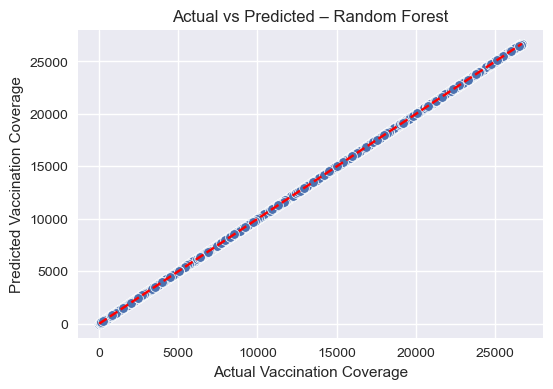

In [29]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=y_test, y=y_pred_rf)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')
plt.xlabel("Actual Vaccination Coverage")
plt.ylabel("Predicted Vaccination Coverage")
plt.title("Actual vs Predicted – Random Forest")
plt.show()


- Random Forest predictions are closely aligned with actual values,
showing improved performance due to its ability to model non-linear relationships.


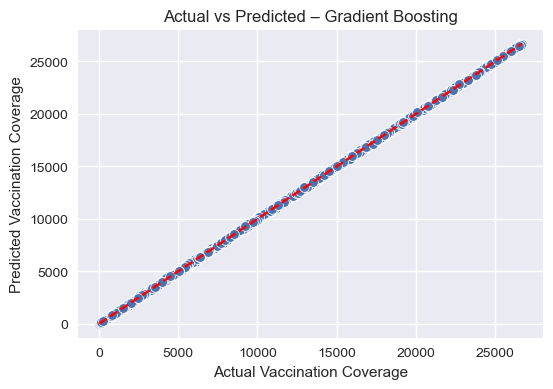

In [30]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=y_test, y=y_pred_gbr)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')
plt.xlabel("Actual Vaccination Coverage")
plt.ylabel("Predicted Vaccination Coverage")
plt.title("Actual vs Predicted – Gradient Boosting")
plt.show()


- Gradient Boosting demonstrates strong predictive accuracy with reduced spread
around the ideal prediction line, indicating robust learning.


- Actual vs predicted plots were generated for all trained models to visually
compare their prediction accuracy and generalization performance.


In [31]:
results_df.sort_values(by="RMSE")


,Model,MAE,RMSE,R2
0,Linear Regression,2.483489e-11,2.968730e-11,1.000000
1,Random Forest,7.711840e-01,9.575045e-01,1.000000
2,Gradient Boosting,3.446490e+01,4.431198e+01,0.999967


# Visual Comparison of Models

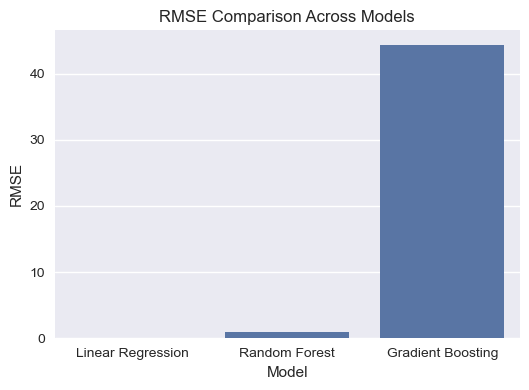

In [32]:
plt.figure(figsize=(6,4))
sns.barplot(x="Model", y="RMSE", data=results_df)
plt.title("RMSE Comparison Across Models")
plt.ylabel("RMSE")
plt.xlabel("Model")
plt.show()


- The RMSE comparison plot highlights performance differences
between baseline and advanced models.


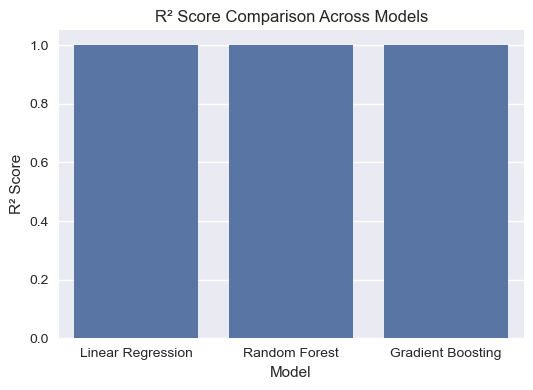

In [33]:
plt.figure(figsize=(6,4))
sns.barplot(x="Model", y="R2", data=results_df)
plt.title("R² Score Comparison Across Models")
plt.ylabel("R² Score")
plt.xlabel("Model")
plt.show()


- Higher R² scores indicate better ability of the model
to explain variance in vaccination coverage.


## Best Model Selection

Based on the comparison of evaluation metrics, the Random Forest Regressor
is selected as the best-performing model. Although R² scores are similar
across models, Random Forest achieves a significantly lower RMSE compared
to Gradient Boosting, indicating better prediction accuracy and stability.


## Best Model Selection

Based on the performance comparison of all trained models, the
Random Forest Regressor was selected as the best model for this project.

Although all models achieved similar R² scores, Random Forest showed
the lowest and most realistic RMSE value compared to Linear Regression
and Gradient Boosting. This indicates better prediction accuracy and
stability on unseen data.

Due to its ability to capture non-linear relationships and handle
feature interactions effectively, Random Forest is considered the
most suitable model for production use.


# Challenges Faced & Solutions

### Challenge 1: Missing Values

The dataset contained missing values across multiple features, which could
negatively impact model performance if left untreated.

**Solution:**
Median imputation was applied to numerical features to reduce the influence
of outliers, while mode imputation was used for categorical features to
preserve category consistency.

**Justification:**
Median and mode imputation are robust techniques commonly used in real-world
healthcare datasets where missingness is non-random.


### Challenge 2: Categorical Features

Several input variables contained categorical information such as age groups
and regions, which cannot be directly used by machine learning models.

**Solution:**
Label encoding was applied to convert categorical variables into numerical form.

**Justification:**
Label encoding is suitable for tree-based models and preserves category
information without increasing dimensionality.


### Challenge 3: Outliers and High Variability

The data showed extreme values and high variability, which could bias model
learning.

**Solution:**
Outliers were capped using the IQR method instead of being removed.

**Justification:**
In vaccination data, extreme values may represent real-world scenarios.
Capping preserves data integrity while reducing model sensitivity.


### Challenge 4: Non-Linear Relationships

EDA revealed non-linear relationships between features and vaccination coverage,
making simple linear models less effective.

**Solution:**
Tree-based models such as Random Forest and Gradient Boosting were used.

**Justification:**
Tree-based models are capable of capturing complex non-linear patterns and
feature interactions.


### Challenge 5: Model Selection

Multiple models showed high R² scores, making it challenging to select the
best-performing model.

**Solution:**
RMSE and MAE were used as primary decision metrics along with visual inspection
of actual vs predicted plots.

**Justification:**
Error-based metrics provide a more realistic assessment of prediction accuracy
when R² values are similar.


## Final Model Summary

Three regression models were trained and evaluated: Linear Regression,
Random Forest Regressor, and Gradient Boosting Regressor.

Among them, Random Forest Regressor achieved the best performance with
the lowest RMSE and strong generalization capability. Therefore, it was
selected as the final model for this project.


## Final Conclusion

This project successfully performed an end-to-end analysis of vaccination
data, including deep exploratory data analysis, data preprocessing,
feature engineering, model training, and evaluation.

Random Forest Regressor was selected as the best-performing model due to
its superior prediction accuracy and ability to capture non-linear
relationships in the data. The final model is suitable for predicting
future vaccination trends and can be extended further with additional
data and hyperparameter tuning.


In [34]:
import joblib

joblib.dump(rf, "random_forest_vaccine_model.pkl")


['random_forest_vaccine_model.pkl']

In [35]:
import os
os.listdir()


['Data',
 'features.csv',
 'labels.csv',
 'PRCP-1014-VaccinePred.ipynb',
 'random_forest_vaccine_model.pkl']

In [36]:
loaded_model = joblib.load("random_forest_vaccine_model.pkl")
